In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
#imported ALL libraries in this cell even the ones used in the last cells
# to avoid import errors in the pytest tests

In [3]:
#Load datasets for EDA

df = pd.read_csv('E:/Downloads/boston.csv')

#data loaded successfully

In [4]:
#Metadata

print ("\n Data Info: ")
df.info()


 Data Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [5]:
#basic Statistics

print ("\n Stats: ")
df.describe()



 Stats: 


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [6]:
#Check for null values
print ("\n Null Values: ")
print (df.isnull().sum())


 Null Values: 
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [7]:
#check for duplicates
print ("\n Duplicates: ")
print ("\n Duplicates: ", df.duplicated().sum())



 Duplicates: 

 Duplicates:  0


In [8]:
#shownig the first 5 rows
print ("Printing the first 5 rows: ")
print (df.head())

Printing the first 5 rows: 
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


In [9]:
#printing last 5 rows

print ("The last 5 rows: ")
print (df.tail())


The last 5 rows: 
        CRIM   ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
501  0.06263  0.0  11.93     0  0.573  6.593  69.1  2.4786    1  273.0   
502  0.04527  0.0  11.93     0  0.573  6.120  76.7  2.2875    1  273.0   
503  0.06076  0.0  11.93     0  0.573  6.976  91.0  2.1675    1  273.0   
504  0.10959  0.0  11.93     0  0.573  6.794  89.3  2.3889    1  273.0   
505  0.04741  0.0  11.93     0  0.573  6.030  80.8  2.5050    1  273.0   

     PTRATIO       B  LSTAT  MEDV  
501     21.0  391.99   9.67  22.4  
502     21.0  396.90   9.08  20.6  
503     21.0  396.90   5.64  23.9  
504     21.0  393.45   6.48  22.0  
505     21.0  396.90   7.88  11.9  


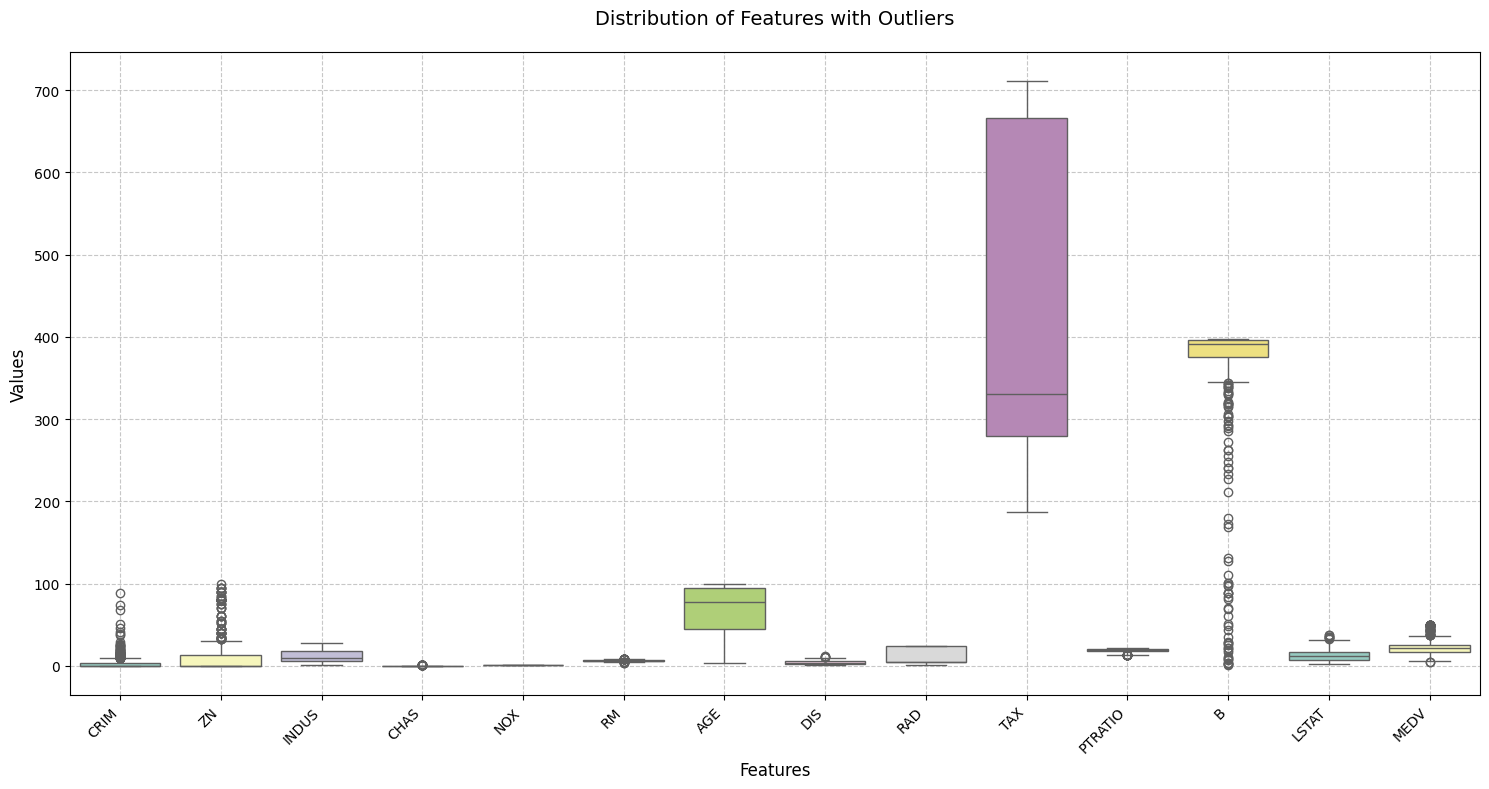

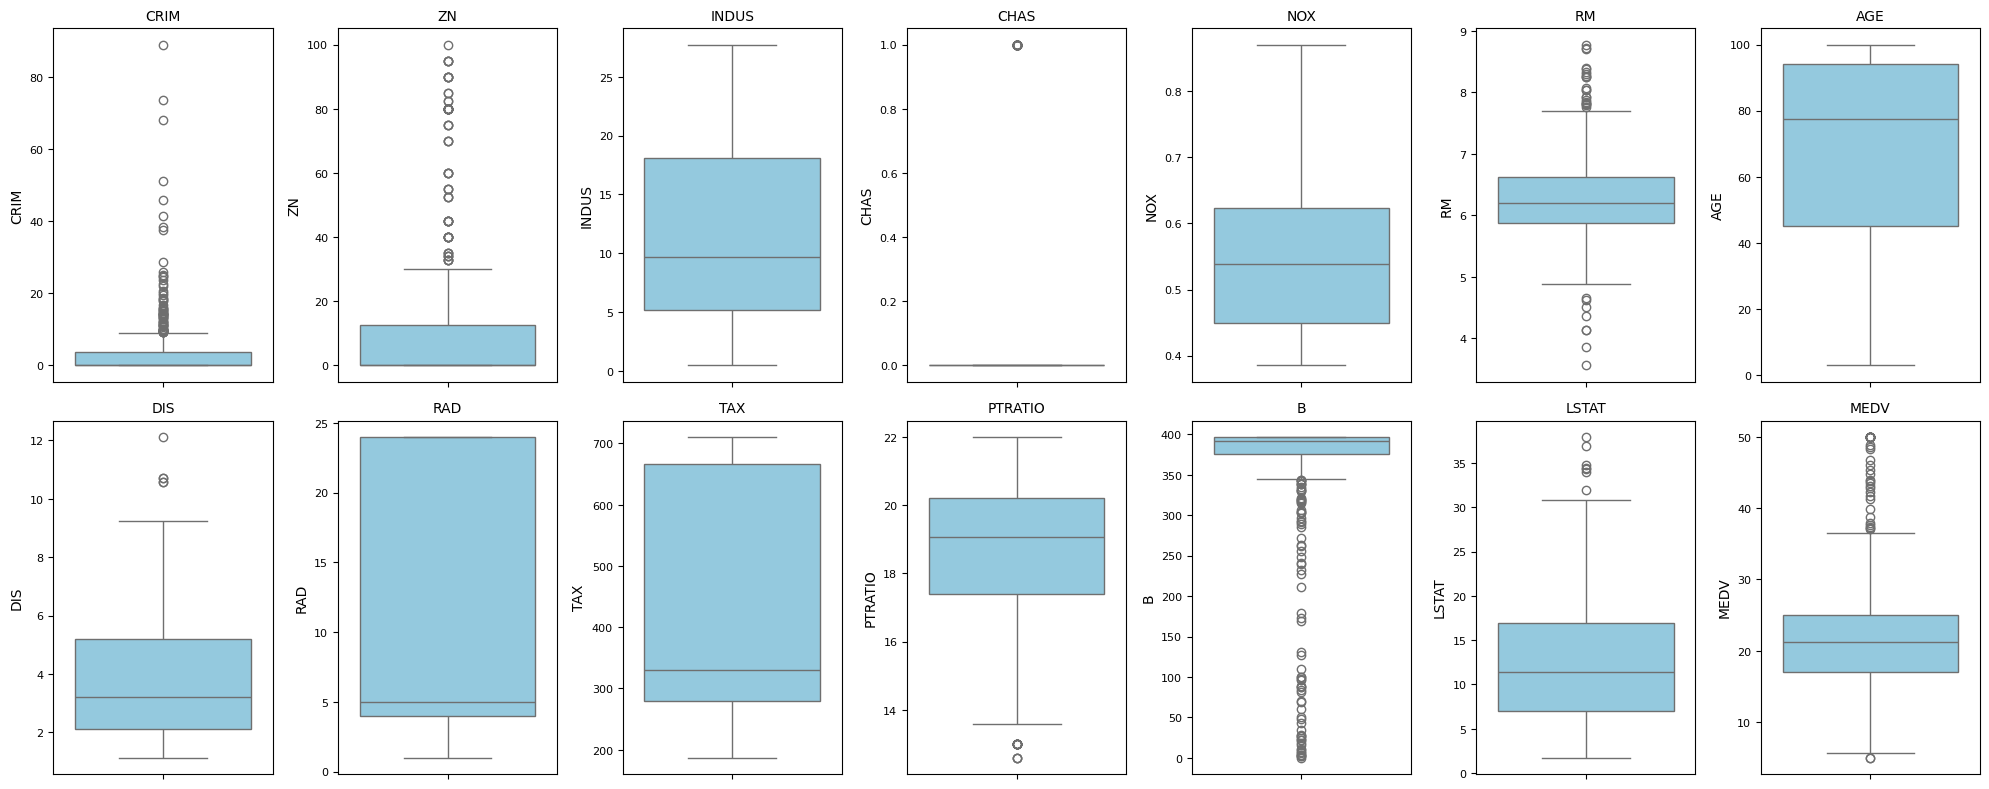

In [10]:
#Data Visualization since no null values or duplicates found
 
#box pot to identify outliers
# Large value ranges (e.g. CRIM, ZN) flatten smaller features, hiding outliers.

plt.figure(figsize=(15, 8))
sns.boxplot(data=df, palette='Set3')

# Customize the plot
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Features with Outliers', pad=20, fontsize=14)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#Large value ranges (e.g. CRIM, ZN) flatten smaller features, so individual boxplots are used.

# Create individual boxplots for each feature
fig, axes = plt.subplots(nrows=2, ncols=7, figsize=(20, 8))
flat_axes = axes.flatten()

# Simple for loop using range and len
for i in range(len(df.columns)):
    sns.boxplot(data=df[df.columns[i]], ax=flat_axes[i], color='skyblue')
    flat_axes[i].set_title(df.columns[i], fontsize=10)
    flat_axes[i].tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.show()

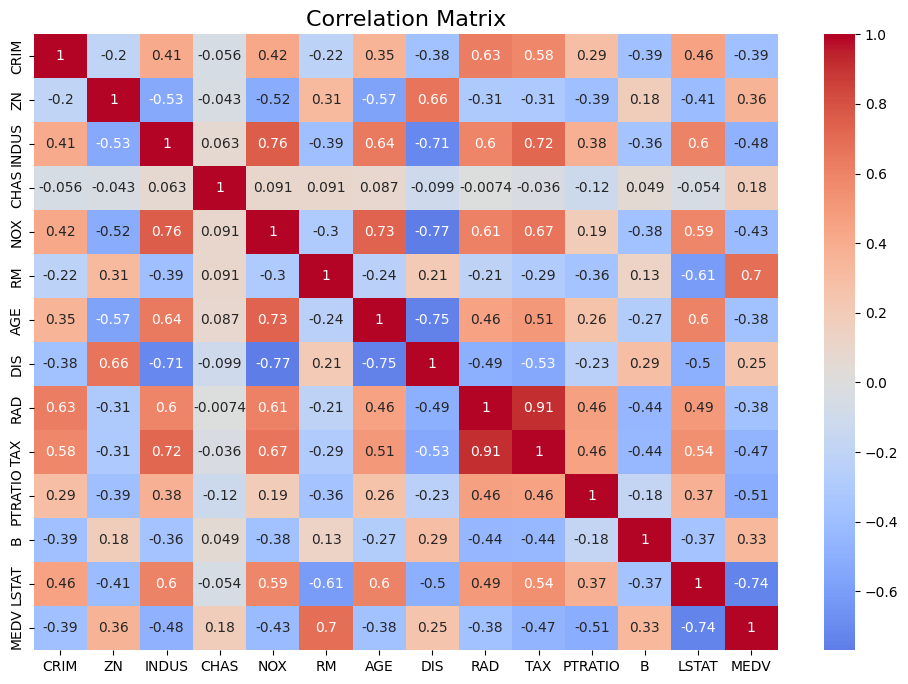

In [11]:
#correlation matrix to assist in Linear Regression

plt.figure (figsize=(12, 8))
sns.heatmap (df.corr(), annot = True, cmap = 'coolwarm', center=0)
plt.title ('Correlation Matrix', fontsize=16)
plt.tight_layout
plt.show()


In [ ]:
# Function to get important features based on correlation with target
def get_important_features(df, target, threshold=0.3):
    correlations = abs(df.corr()[target]).sort_values(ascending=False)
    return correlations[correlations > threshold].index.tolist()[1:]  # Exclude target itself


: 

In [ ]:
#Disttribution plot of target variable ('MEDV')

plt.figure (figsize=(12, 8))
sns.histplot (df['MEDV'], bins=30, kde=True, color='purple')
plt.title ('Distribution of Target Variable (MEDV)', fontsize=16)
plt.xlabel ('Median Value (MEDV)')
plt.ylabel ('Frequency/Count')
plt.show()


#rightly skewed
#clear cutoff at 50k


In [ ]:
#Q-Q pliot to check normality of target variable (MEDV)
#if the points follow the diagonal line, the data is normally distributed.


plt.figure(figsize = (12,8))
stats.probplot(df['MEDV'], dist='norm', plot=plt)
plt.title("Q-Q plot of House Prices (MEDV)")
plt.show()

In [ ]:
#display correlation with MEDV (Target Variable)
#r > 0.7  strong correlation
#r = 0.3–0.7  Moderate correlation
#r < 0.3  Weak correlation
#features with moderate or strong correlation are useful for linear regression


print ("\n Correlation with MEDV: ")
correlations = df.corr()['MEDV'].sort_values(ascending=False)
print (correlations)

In [ ]:
def get_important_features(df, target, threshold=0.2):
    """Select features that have strong relationship with house prices"""
    correlations = abs(df.corr()[target]).sort_values(ascending=False)
    # Keep only features with correlation > 0.5 (strong relationships)
    return correlations[correlations > threshold].index.tolist()[1:]

def remove_outliers(df, columns):
    """Remove extreme values that could skew our predictions"""
    df_clean = df.copy()
    for column in columns:
        # Find the normal range for each feature
        Q1 = df_clean[column].quantile(0.25)  # 25th percentile
        Q3 = df_clean[column].quantile(0.75)  # 75th percentile
        IQR = Q3 - Q1  # Normal range
        
        # Define what we consider "extreme" values
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Keep only normal values
        df_clean = df_clean[(df_clean[column] >= lower_bound) & 
                           (df_clean[column] <= upper_bound)]
    return df_clean

def select_features(df, target_column):
    """Pick the best features for predicting house prices"""
    # 1. First find which features are strongly related to house prices
    important_features = get_important_features(df, target_column, threshold=0.2)
    print("\nFeatures strongly related to house prices:")
    print(important_features)
    
    # 2. Remove extreme values that could mislead our model
    features_to_clean = important_features + [target_column]
    df_cleaned = remove_outliers(df[features_to_clean], features_to_clean)
    print(f"\nRemoved {len(df) - len(df_cleaned)} unusual data points")
    
    return df_cleaned, important_features

# Clean our data and select features
df_cleaned, selected_features = select_features(df, 'MEDV')

# Prepare data for modeling
X = df_cleaned[selected_features]
y = df_cleaned['MEDV']



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(  #splitting for training and testing
X, y, test_size=0.2, random_state=42)   #20% test size, 80% train size
                                         # random state for reproducibility

In [ ]:
scaler = MinMaxScaler() #features scaled so that all are on the same scale
X_train = scaler.fit_transform(X_train) #else tax or zn with heavy numbers will dominate model
X_test = scaler.transform(X_test)


In [ ]:
model = LinearRegression() #Linear regression model initiated (empty)
model.fit(X_train, y_train) #model trained on training data .fit helps find the best fit 


: 

In [ ]:
y_pred = model.predict(X_test)  # predictions made on test data
print (y_pred)

In [ ]:
mse = mean_squared_error(y_test, y_pred) #MSE caluculated to evaluate model performance
                                         #diff bw actual and predicted values (lower the better)
r2 = r2_score(y_test, y_pred) # R² score calculated to evaluate model performance
                              # 0-1 (1 is perfect fit, 0 is no fit)
print(f'Mean Squared Error: {mse:.2f}')
print(f'R² Score: {r2:.2f}') 


In [ ]:
residuals = y_test - y_pred #residual = actual - predicted
# Plotting residuals to check for patterns          
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Actual Prices')
plt.ylabel('Residuals')
plt.title('Residuals vs Actual Prices')
plt.show()


In [ ]:
# Actual vs Predicted Plot with explanations
plt.figure(figsize=(12, 8))

# Scatter plot with color coding based on prediction accuracy
residuals = abs(y_test - y_pred)
scatter = plt.scatter(y_test, y_pred, 
                     c=residuals, 
                     cmap='RdYlGn_r',  # Red for large errors, green for small errors
                     alpha=0.6,
                     s=100)  # Larger point size

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'k--', 
         lw=2, 
         label='Perfect Predictions')

# Add colorbar to show error magnitude
plt.colorbar(scatter, label='Prediction Error ($1000s)')

# Formatting
plt.xlabel('Actual House Prices ($1000s)', fontsize=12)
plt.ylabel('Predicted House Prices ($1000s)', fontsize=12)
plt.title('House Price Predictions: Actual vs Predicted\n'
          f'R² Score: {r2:.2f}', 
          fontsize=14, 
          pad=20)

# Add explanatory text
plt.text(0.02, 0.98, 
         'How to read this plot:\n' +
         '• Points on dashed line = perfect predictions\n' +
         '• Green points = small prediction errors\n' +
         '• Red points = large prediction errors\n' +
         f'• Model explains {r2:.1%} of price variations',
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8),
         fontsize=10,
         verticalalignment='top')

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



In [ ]:
import joblib

# Save model and scaler
joblib.dump(model, 'linear_regression_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
# Save selected features
joblib.dump(selected_features, 'selected_features.pkl')

